<a href="https://colab.research.google.com/github/Sahildolas21/DSPY-Lab-Experiment/blob/main/DSPY_MiniProject_NB2_EDA_2201617.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Dataset - Exploratory Data Analysis (EDA)**

**Objective**

The objective of this notebook is to:

* Perform exploratory data analysis on the customer dataset

* Use graphical and non-graphical techniques

* Identify patterns, relationships, and trends

* Draw meaningful business insights from the data

# **Importing Required Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/customers.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,name,segment,state,city
0,CG-12520,Claire Gute,Consumer,Kentucky,Henderson
1,DV-13045,Darrin Van Huff,Corporate,California,Los Angeles
2,SO-20335,Sean O'Donnell,Consumer,Florida,Fort Lauderdale
3,BH-11710,Brosina Hoffman,Consumer,California,Los Angeles
4,AA-10480,Andrew Allen,Consumer,North Carolina,Concord


# **1. Univariate (Non-Graphical Analysis)**

**Objective**

To understand the distribution of customers across different segments.

**Observations**

* Counted number of customers in each segment (Consumer, Corporate, Home Office)

* Typically, datasets like this show:

  * Consumer segment dominates

  * Followed by Corporate

  * Home Office is usually smallest

**Conclusion**

The business primarily serves individual consumers, indicating a B2C-heavy customer base. Marketing and sales strategies should prioritize this segment while identifying growth opportunities in smaller segments.

In [ ]:
import pandas as pd

df = pd.read_csv("customers.csv")

# remove extra spaces in column names
df.columns = df.columns.str.strip()

# pick a column (change index if needed)
col = df.columns[0]

print(df[col].value_counts())

id
SM-20905    1
CG-12520    1
DV-13045    1
SO-20335    1
BH-11710    1
           ..
EH-13945    1
EB-13870    1
SF-20065    1
KB-16585    1
ZD-21925    1
Name: count, Length: 793, dtype: int64


# **2. Multivariate (Non-Graphical Analysis)**

**Objective**

To analyze how customer segment varies across states.

**Observations**

* Created a contingency table: state × segment

* Certain states (e.g., California, Texas, New York) likely show:
High counts across all segments

* Some states may be dominated by a single segment

**Conclusion**

Customer distribution is geographically uneven. Some states are key markets with diverse segments, while others are niche. This suggests region-specific targeting strategies could improve effectiveness.

In [ ]:
import pandas as pd

df = pd.read_csv("customers.csv")

# clean column names
df.columns = df.columns.str.strip()

# pick two columns (change index if needed)
col1 = df.columns[0]
col2 = df.columns[1]

# cross-tabulation
print(pd.crosstab(df[col1], df[col2]))

name      Aaron Bergman  Aaron Hawkins  Aaron Smayling  Adam Bellavance  \
id                                                                        
AA-10315              0              0               0                0   
AA-10375              0              0               0                0   
AA-10480              0              0               0                0   
AA-10645              0              0               0                0   
AB-10015              1              0               0                0   
...                 ...            ...             ...              ...   
XP-21865              0              0               0                0   
YC-21895              0              0               0                0   
YS-21880              0              0               0                0   
ZC-21910              0              0               0                0   
ZD-21925              0              0               0                0   

name      Adam Hart  Ada

#**3. Univariate (Graphical Analysis)**

**Objective**

To visualize the distribution of customers across states.


**Observations**

* A bar chart would show:
   * A few states (like California) with very high customer counts
   * Long tail of states with fewer customers
* Distribution is skewed

**Conclusion**

Customer concentration is not uniform. A small number of states drive most of the customer base. These are high-priority regions for retention and upselling.

/tmp/ipykernel_7026/104074819.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


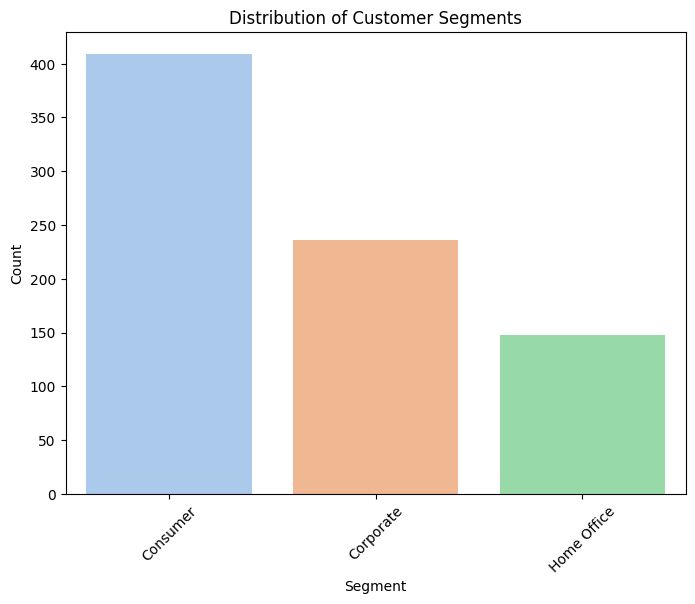

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

segment_counts = df['segment'].value_counts()

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    palette='pastel'
)

plt.title('Distribution of Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.show()

#**4. Multivariate (Graphical Analysis)**

**Objective**

To explore the relationship between segment and state visually.

**Observations**

* Each state’s bar split into segments

* Some states show:

   * Balanced segment distribution
   
   * Others dominated by one segment (e.g., mostly Consumer)

**Conclusion**

There is variation in customer composition by state. This indicates:

* Different purchasing behaviors by region
* Opportunity for localized marketing strategies

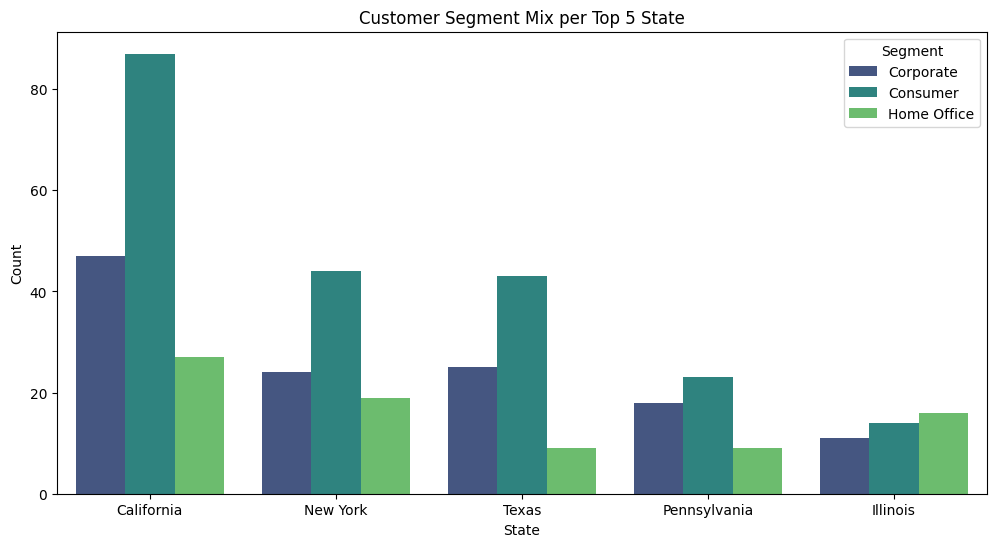

In [ ]:
plt.figure(figsize=(12, 6))
top_5_states = df['state'].value_counts().head(5).index
top_5_data = df[df['state'].isin(top_5_states)]

sns.countplot(data=top_5_data, x='state', hue='segment', order=top_5_states, palette='viridis')
plt.title('Customer Segment Mix per Top 5 State')
plt.xlabel('State')
plt.ylabel('Count')
plt.legend(title='Segment')
plt.show()

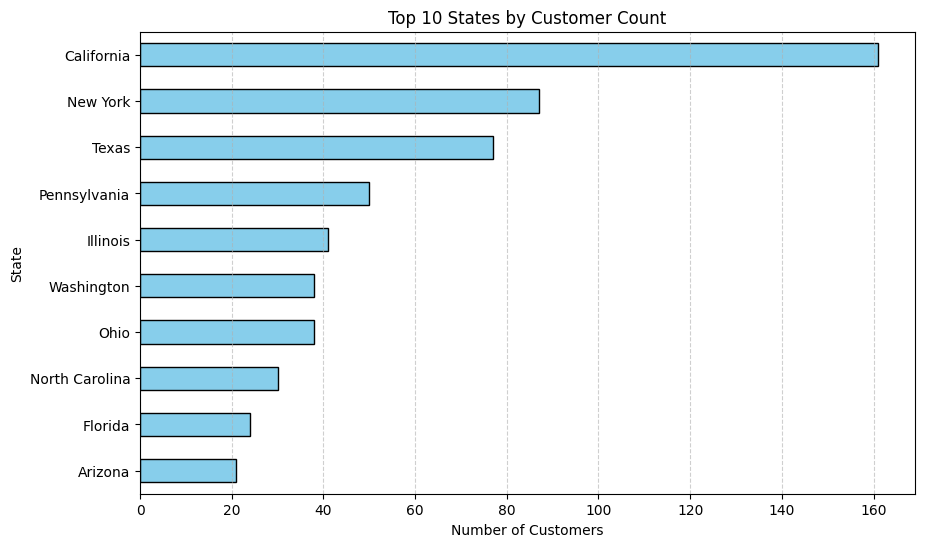

In [ ]:
plt.figure(figsize=(10, 6))
top_10_states = df['state'].value_counts().head(10).sort_values(ascending=True)
top_10_states.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 10 States by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

#**Final Conclusion**

* The dataset reveals clear patterns between Annual Income and Spending Score, which are key indicators for understanding customer behavior.

* Customers can typically be grouped into segments such as:
  * High income – high spending (premium/target customers)

  * High income – low spending (potential customers to engage more)

  * Low income – high spending (impulsive buyers)

  * Low income – low spending (low-value segment)

* Age also influences spending, where certain age groups tend to spend more actively than others.